# COMP4318/5318 Assignment 2: Image Classification

### Group number: 202  , SID1: 540179745 , SID2: 550460880, SID3: 550057510, SID4: 541012132

## Setup and dependencies

In [ ]:
from tensorflow.keras import models, layers, callbacks, optimizers, mixed_precision
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
import numpy as np
import itertools
import random
import joblib
import time
import glob
import re
import os

In [ ]:
# Google colab connection if needed
from google.colab import drive
drive.mount('/content/drive')
os.chdir('/content/drive/MyDrive/Tumor Classification')

Mounted at /content/drive


## 1. Data loading, exploration, and preprocessing


In [ ]:
# Load Data
X_train = np.load('Data/X_train.npy')
y_train = np.load('Data/y_train.npy')
X_test = np.load('Data/X_test.npy')
y_test = np.load('Data/y_test.npy')

### Examples of preprocessed data

In [ ]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print(f"X_test shape:", X_test.shape)
print(f"y_test shape: {y_test.shape}")
print(f"Pixel range: {np.min(X_train)} to {np.max(X_train)}")
classes = np.unique(y_train)
print("Classes:", classes)
print("Number of classes:", len(classes),"\n")

X_train shape: (32000, 28, 28, 3)
y_train shape: (32000,)
X_test shape: (8000, 28, 28, 3)
y_test shape: (8000,)
Pixel range: 0 to 255
Classes: [0 1 2 3 4 5 6 7 8]
Number of classes: 9 



In [ ]:
categories = {
  0:"Adipose",
  1:"Background",
  2:"Debris",
  3:"Lymphocytes",
  4:"Mucus",
  5:"Muscle",
  6:"Normal",
  7:"Stroma",
  8:"Tumor"
}

### Class distribution

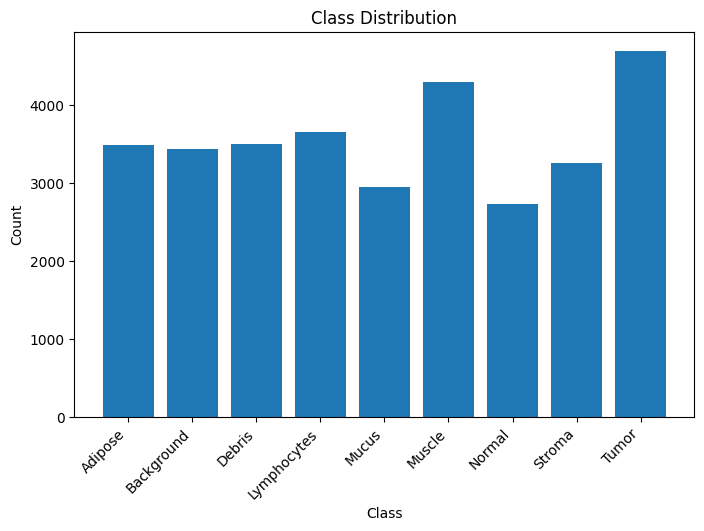

In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
labels = [categories[idx] for idx in unique]
plt.figure(figsize=(8,5))
bars = plt.bar(labels, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.show()

### Class samples

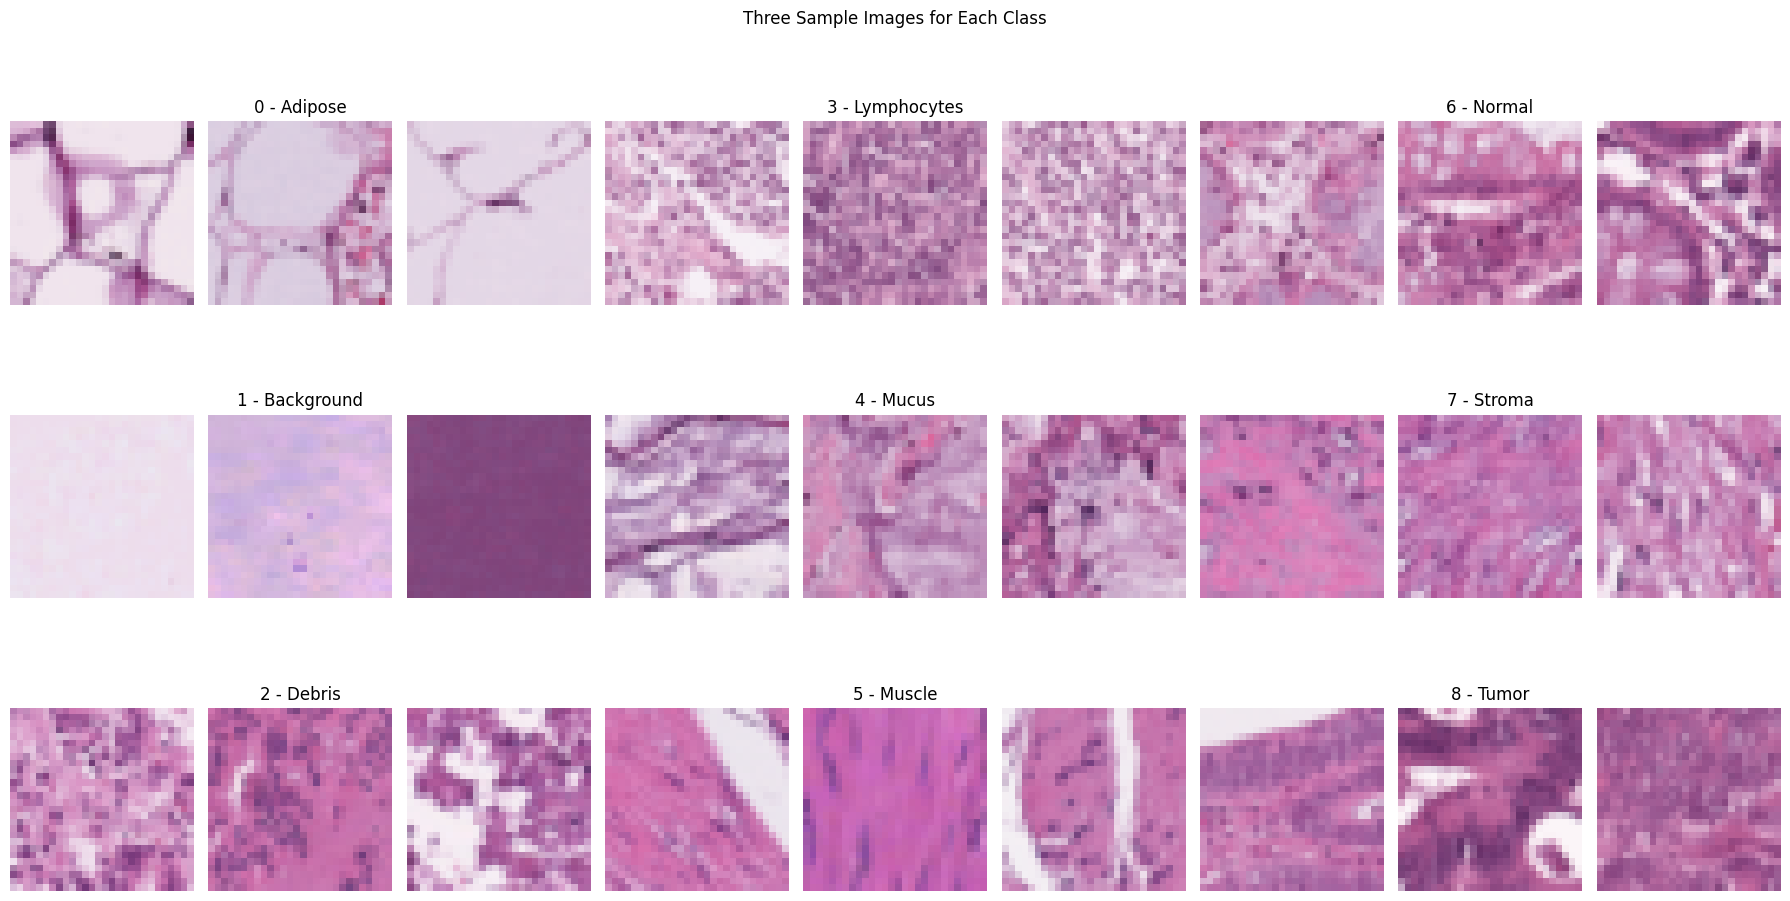

In [ ]:
classes = np.unique(y_train)
y_1d = y_train.ravel()
fig, axes = plt.subplots(3, 9, figsize=(18, 10))
for i, cls in enumerate(classes[:9]):
  idxs = np.where(y_1d == cls)[0][:3]
  group_col = i // 3
  row = i % 3
  for j, idx in enumerate(idxs):
    col = group_col * 3 + j
    ax = axes[row, col]
    ax.imshow(X_train[idx])
    ax.axis("off")
    if j == 1:
      ax.set_title(str(cls) + " - " + categories[cls])
plt.suptitle("Three Sample Images for Each Class")
plt.tight_layout()
plt.show()

### Average and standard deviation of brightness

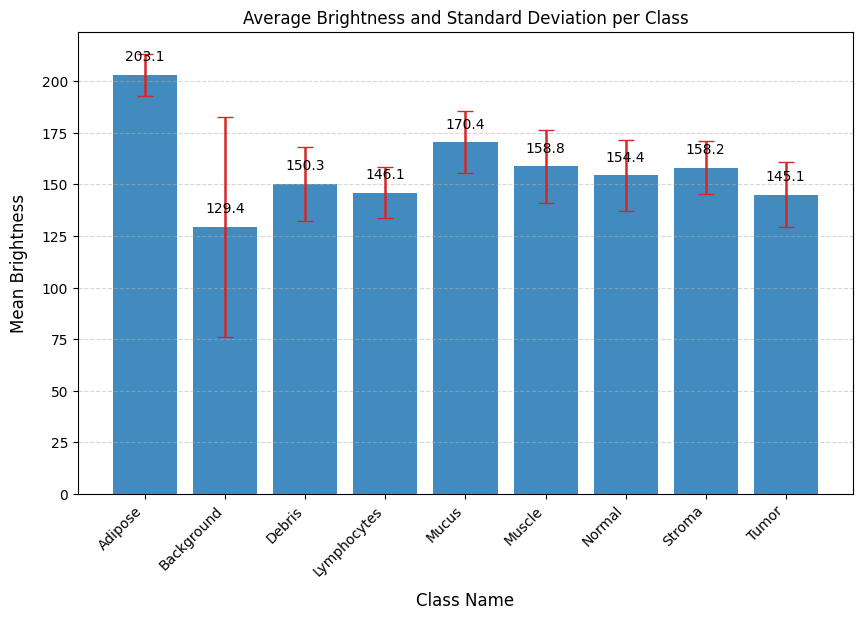

In [ ]:
weights = np.array([0.299, 0.587, 0.114])
img_brightness = np.mean(X_train @ weights, axis=(1, 2))
unique_classes = np.unique(y_train)
labels = [categories[idx] for idx in unique_classes]
stats = [
    (np.mean(img_brightness[y_train.ravel() == cls]),
     np.std(img_brightness[y_train.ravel() == cls]))
    for cls in unique_classes
]
means, stds = zip(*stats)
plt.figure(figsize=(10, 6), dpi=100)
plt.grid(axis="y", linestyle="--", alpha=0.5)

bars = plt.bar(
    labels,
    means,
    yerr=stds,
    capsize=6,
    alpha=0.85,
    error_kw={"ecolor": "#d62728", "lw": 1.8},
)

for bar, mean in zip(bars, means):
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        mean + max(stds) * 0.1,
        f"{mean:.1f}",
        ha="center",
        va="bottom"
    )

plt.title("Average Brightness and Standard Deviation per Class")
plt.xlabel("Class Name", fontsize=12, labelpad=10)
plt.ylabel("Mean Brightness", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha="right")
plt.show()

### Set random seed and pre-processing

In [ ]:
random.seed(0)
np.random.seed(0)
tf.random.set_seed(0)

In [ ]:
# Data augment
def augment(x, y):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.rot90(x, k=tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32))
    x = tf.image.random_brightness(x, max_delta=0.2)
    x = tf.image.random_contrast(x, lower=0.8, upper=1.2)
    x = tf.clip_by_value(x, 0.0, 255.0)
    return x, y

# NN data pre-processing
def prepare_dataset(X, y, batch_size=1024, is_training=True):
    X = tf.cast(X, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.cache()

    if is_training:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(buffer_size=min(10000, len(X)))
    ds = ds.batch(batch_size, drop_remainder=is_training)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    return ds

In [ ]:
# Random forest data pre-processing
# Flatten data
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat  = X_test.reshape(len(X_test), -1)

# Normalize data
scaler = StandardScaler()
scaler.fit(X_train_flat)
X_train_scaled = scaler.transform(X_train_flat)
X_test_scaled  = scaler.transform(X_test_flat)

# Apply PCA
pca = PCA(n_components=10, svd_solver='randomized', random_state=0)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [ ]:
# Use XLA andB F16 to speed up tranning
mixed_precision.set_global_policy('mixed_bfloat16')
tf.config.optimizer.set_jit(True)

# Split train and validation data
X_train_sub, X_val, y_train_sub, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=0)

# MLP and CNN data pre-processing
train_ds = prepare_dataset(X_train_sub, y_train_sub, batch_size=1024, is_training=True)
val_ds = prepare_dataset(X_val, y_val, batch_size=1024, is_training=False)

## 2. Algorithm design and setup

### Algorithm of choice from first six weeks of course

In [ ]:
# Random forest model
def random_forest_model(X_train, y_train, param_grid, cv):
    rf = RandomForestClassifier(n_jobs=-1, random_state=0)
    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=1
    )
    grid_search.fit(X_train, y_train)
    return grid_search

### Fully connected neural network

In [ ]:
# MLP with adjustable hidden layer size, activation function, learning rate
def build_mlp(input_shape=(28, 28, 3), num_classes=9, hidden_sizes=[512, 256, 128], activation='relu', learning_rate=1e-4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Flatten()(inputs)
    for i, h in enumerate(hidden_sizes):
        x = layers.Dense(h, kernel_initializer='he_normal', use_bias=False)(x) # HE initalization for improve stability
        x = layers.BatchNormalization()(x) # Normalize layer output to improve stability
        x = layers.Activation(activation)(x)
        x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.AdamW(learning_rate=learning_rate, weight_decay=0.05),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=True # XLA speed up
    )
    return model

### Convolutional neural network

In [ ]:
# CNN with adjustable filter number, kernel size, learning rate by referencing and simplifying ResNet
def basic_block(x, filters, kernel_size=3, stride=1):
    shortcut = x
    if stride != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding='same', use_bias=False)(x)
        shortcut = layers.BatchNormalization()(shortcut)
    x = layers.Conv2D(filters, kernel_size, strides=stride, padding='same', use_bias=False, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, kernel_size, strides=1, padding='same', use_bias=False, kernel_initializer='he_normal')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Add()([x, shortcut]) # Residual Learning by skip connection
    x = layers.Activation('relu')(x)
    return x

def build_cnn(input_shape=(28, 28, 3), num_classes=9, filters=[64, 128], kernel_size=3, learning_rate=1e-4):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(filters[0], 3, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = basic_block(x, filters[0], kernel_size, 1)
    x = basic_block(x, filters[1], kernel_size, 2)
    x = layers.MaxPooling2D(2)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax', dtype='float32')(x)
    model = models.Model(inputs, outputs)
    model.compile(
        optimizer=optimizers.AdamW(learning_rate, weight_decay=0.01),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
        jit_compile=True # XLA speed up
    )
    return model

## 3. Hyperparameter tuning

In [ ]:
# Track model runtime
class TimeTrackerCallback(callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        self.model.total_runtime = time.time() - self.start_time

In [ ]:
# Display the trend of training and validation accuracy over epochs
def plot_accuracy(history):
  plt.plot(history.history['accuracy'], label='train acc')
  plt.plot(history.history['val_accuracy'], label='val acc')
  plt.title('Accuracy')
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.tight_layout()
  plt.show()

### Random Forest

In [ ]:
# Setting hyperparameter groups
cvKFold=StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
param_grid = {
    'n_estimators': [250, 500],
    'max_depth': [25, 50],
    'min_samples_split': [2, 5]
}

# Train random forest model
grid_search = random_forest_model(X_train_pca, y_train, param_grid, cvKFold)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


In [ ]:
save_path = "Checkpoint/Random Forest/grid_search.pkl"
os.makedirs(os.path.dirname(save_path), exist_ok=True)
joblib.dump(grid_search, save_path)

['Checkpoint/Random Forest/grid_search.pkl']

### Fully connected neural network

Training Group 0 (h=128-64-32, sigmoid, lr=0.0001)...
-> Group 0 Finished! Runtime: 911.1s
Training Group 1 (h=128-64-32, sigmoid, lr=0.001)...
-> Group 1 Finished! Runtime: 741.2s
Training Group 2 (h=128-64-32, relu, lr=0.0001)...
-> Group 2 Finished! Runtime: 848.1s
Training Group 3 (h=128-64-32, relu, lr=0.001)...
-> Group 3 Finished! Runtime: 753.3s
Training Group 4 (h=256-128-64, sigmoid, lr=0.0001)...
-> Group 4 Finished! Runtime: 928.7s
Training Group 5 (h=256-128-64, sigmoid, lr=0.001)...
-> Group 5 Finished! Runtime: 813.8s
Training Group 6 (h=256-128-64, relu, lr=0.0001)...
-> Group 6 Finished! Runtime: 894.8s
Training Group 7 (h=256-128-64, relu, lr=0.001)...
-> Group 7 Finished! Runtime: 908.4s


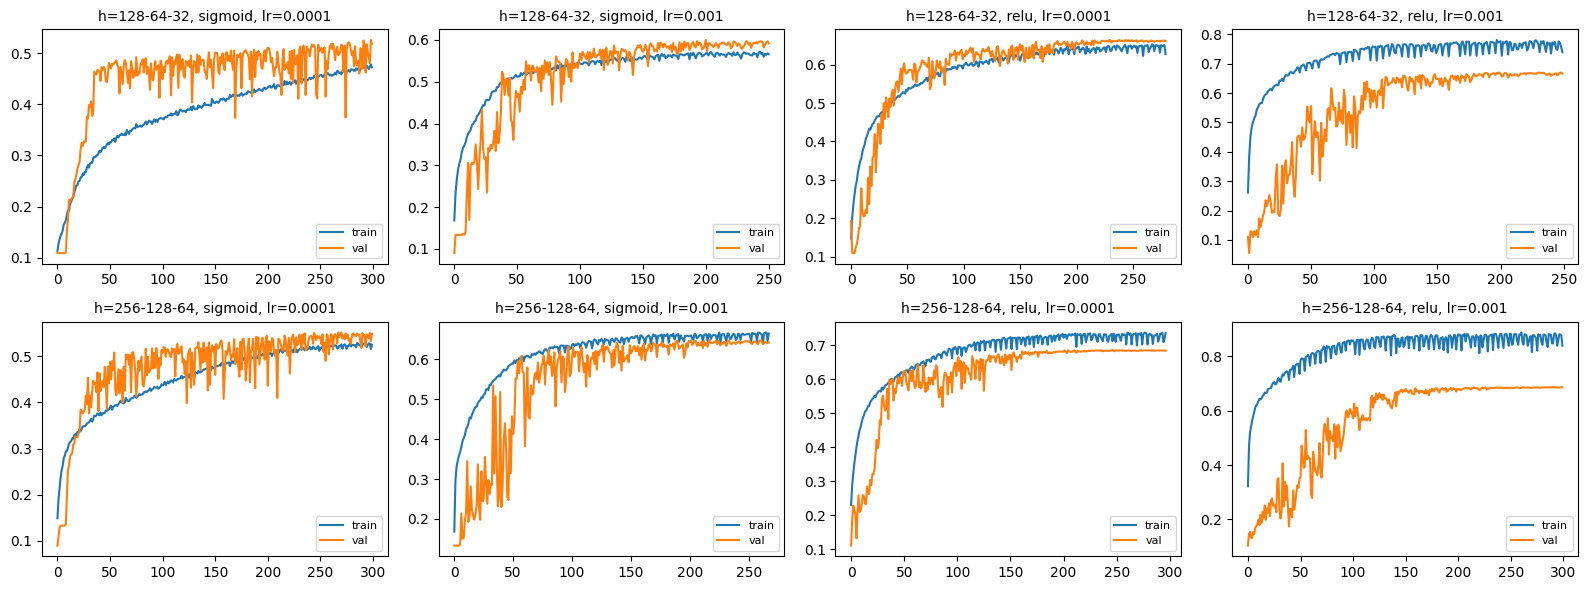

In [ ]:
param = {
    "hidden_sizes": [[128, 64, 32], [256, 128, 64]],
    "activation": ["sigmoid", "relu"],
    "learning_rate": [1e-4, 1e-3],
}
param_list = list(itertools.product(*param.values()))
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
for i, ((h_sizes, act, lr), ax) in enumerate(zip(param_list, axes.flatten())):
    hname = "-".join(map(str, h_sizes))
    title = f"h=[{hname}], {act}, lr={lr}"
    ckpt_path = f"Checkpoint/Multilayer Perceptron/MLP_h{hname}_act{act}_lr{lr}.keras"
    print(f"Training Group {i} ({title})...")
    time_tracker = TimeTrackerCallback()
    model = build_mlp(hidden_sizes=h_sizes, activation=act, learning_rate=lr)
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=300, verbose=0,
        callbacks=[
            callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=15),
            callbacks.EarlyStopping("val_accuracy", patience=50, restore_best_weights=True),
            time_tracker,
            callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
        ],
    )

    print(f"-> Group {i} Finished! Runtime: {time_tracker.model.total_runtime:.1f}s")
    ax.plot(history.history["accuracy"], label="train")
    ax.plot(history.history["val_accuracy"], label="val")
    ax.set_title(title, fontsize=9)
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

### Convolutional neural network

Training Group 0 (filters=[64-128], k=3, lr=0.0001)...
-> Group 0 Finished! Runtime: 1460.8s
Training Group 1 (filters=[64-128], k=3, lr=0.001)...
-> Group 1 Finished! Runtime: 1441.8s
Training Group 2 (filters=[64-128], k=5, lr=0.0001)...
-> Group 2 Finished! Runtime: 1907.1s
Training Group 3 (filters=[64-128], k=5, lr=0.001)...
-> Group 3 Finished! Runtime: 1883.7s
Training Group 4 (filters=[128-256], k=3, lr=0.0001)...
-> Group 4 Finished! Runtime: 3490.9s
Training Group 5 (filters=[128-256], k=3, lr=0.001)...
-> Group 5 Finished! Runtime: 3457.4s
Training Group 6 (filters=[128-256], k=5, lr=0.0001)...
-> Group 6 Finished! Runtime: 4924.0s
Training Group 7 (filters=[128-256], k=5, lr=0.001)...
-> Group 7 Finished! Runtime: 4805.9s


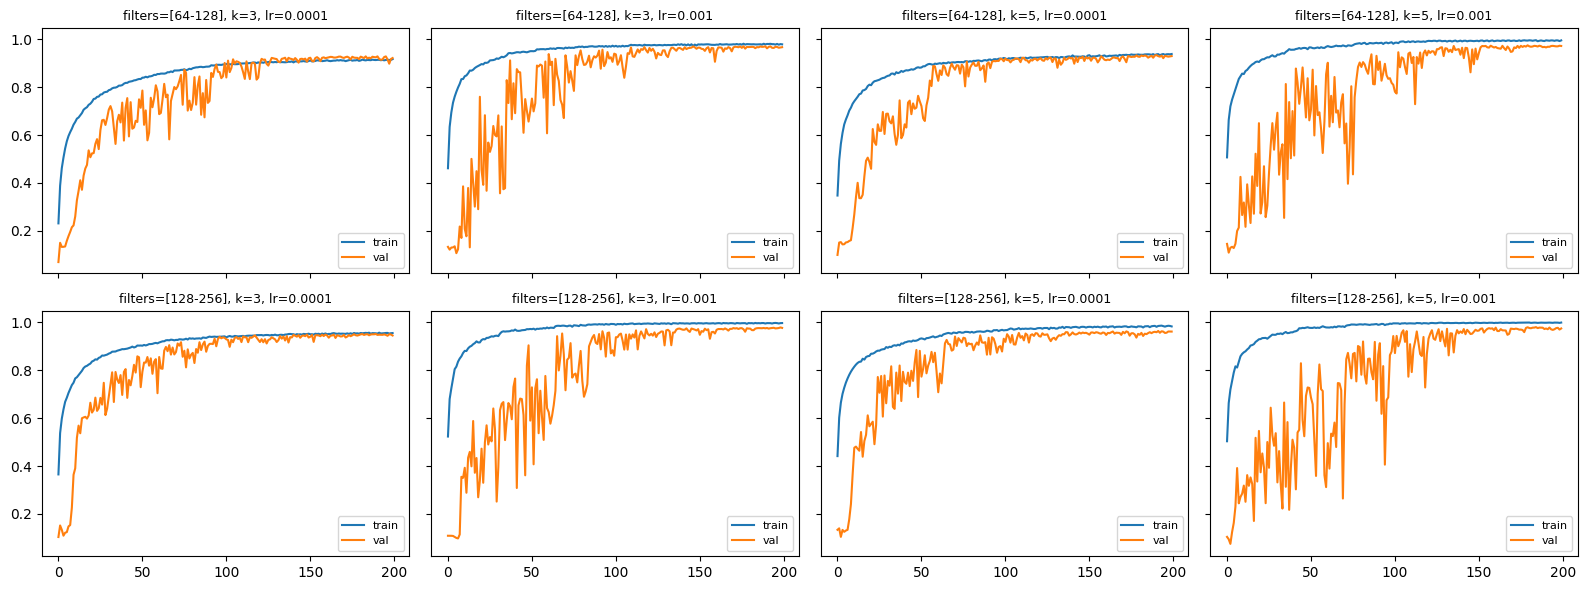

In [ ]:
param = {
    'filters': [[64, 128], [128, 256]],
    'kernel_size': [3, 5],
    'learning_rate': [1e-4, 1e-3]
}
param_list = list(itertools.product(*param.values()))
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
for i, ((filters, k_size, lr), ax) in enumerate(zip(param_list, axes.flatten())):
    fname = "-".join(map(str, filters))
    title = f"filters=[{fname}], k={k_size}, lr={lr}"
    ckpt_path = f"Checkpoint/Convolutional Neural Network/CNN_f{fname}_k{k_size}_lr{lr}.keras"
    print(f"Training Group {i} ({title})...")
    time_tracker = TimeTrackerCallback()
    model = build_cnn(filters=filters, kernel_size=k_size, learning_rate=lr)
    history = model.fit(
        train_ds, validation_data=val_ds, epochs=200, verbose=0,
        callbacks=[
            callbacks.ReduceLROnPlateau("val_loss", factor=0.5, patience=15),
            callbacks.EarlyStopping("val_accuracy", patience=40, restore_best_weights=True),
            time_tracker,
            callbacks.ModelCheckpoint(ckpt_path, monitor="val_accuracy", save_best_only=True),
        ],
    )
    print(f"-> Group {i} Finished! Runtime: {time_tracker.model.total_runtime:.1f}s")
    ax.plot(history.history["accuracy"], label="train")
    ax.plot(history.history["val_accuracy"], label="val")
    ax.set_title(title, fontsize=9)
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Model Comparison

### Random Forest

In [ ]:
rf_path = "Checkpoint/Random Forest/grid_search.pkl"
grid_search = joblib.load(save_path)
cv_results = grid_search.cv_results_
for i in range(len(cv_results["params"])):
    mean_score = cv_results["mean_test_score"][i]
    mean_time = cv_results["mean_fit_time"][i]
    params = cv_results["params"][i]
    print(f"{i+1:<6} Accuracy:{mean_score:<25.4f}Time:{mean_time:<20.2f}Params:{params}")
print("-" * 100)
print("Best hyperparameters: " + str(grid_search.best_params_))
print("Best Score: " + str(grid_search.best_score_))

1      Accuracy:0.7072                   Time:31.35               Params:{'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 250}
2      Accuracy:0.7093                   Time:57.98               Params:{'max_depth': 25, 'min_samples_split': 2, 'n_estimators': 500}
3      Accuracy:0.7060                   Time:28.48               Params:{'max_depth': 25, 'min_samples_split': 5, 'n_estimators': 250}
4      Accuracy:0.7068                   Time:56.61               Params:{'max_depth': 25, 'min_samples_split': 5, 'n_estimators': 500}
5      Accuracy:0.7079                   Time:29.02               Params:{'max_depth': 50, 'min_samples_split': 2, 'n_estimators': 250}
6      Accuracy:0.7087                   Time:58.28               Params:{'max_depth': 50, 'min_samples_split': 2, 'n_estimators': 500}
7      Accuracy:0.7065                   Time:28.51               Params:{'max_depth': 50, 'min_samples_split': 5, 'n_estimators': 250}
8      Accuracy:0.7075                   Time:56

### Fully Connected Neural Network

In [ ]:
best_score, best_model_name = -1, ""
print("\n" + "=" * 90)
print(f"{'Index':<6} {'Accuracy':<15} {'Model File'}")
print("-" * 90)
for i, ckpt_path in enumerate(glob.glob("Checkpoint/Multilayer Perceptron/*.keras")):
    model = tf.keras.models.load_model(ckpt_path, compile=True)
    _, val_acc = model.evaluate(val_ds, verbose=0)
    file_name = ckpt_path.split("/")[-1]
    print(f"{i+1:<6} {val_acc:<15.4f} {file_name}")
    if val_acc > best_score:
        best_score = val_acc
        best_model_name = file_name
print("-" * 90)
print(f"Best Model: {best_model_name}")
print(f"Best Score: {best_score:.4f}")
print("=" * 90)


Index  Accuracy        Model File
------------------------------------------------------------------------------------------
1      0.5258          MLP_h128-64-32_actsigmoid_lr0.0001.keras
2      0.5998          MLP_h128-64-32_actsigmoid_lr0.001.keras
3      0.6647          MLP_h128-64-32_actrelu_lr0.0001.keras
4      0.6695          MLP_h128-64-32_actrelu_lr0.001.keras
5      0.5516          MLP_h256-128-64_actsigmoid_lr0.0001.keras
6      0.6488          MLP_h256-128-64_actsigmoid_lr0.001.keras
7      0.6856          MLP_h256-128-64_actrelu_lr0.0001.keras
8      0.6869          MLP_h256-128-64_actrelu_lr0.001.keras
------------------------------------------------------------------------------------------
Best Model: MLP_h256-128-64_actrelu_lr0.001.keras
Best Score: 0.6869


### Convolutional Neural Network

In [ ]:
best_score, best_model_name = -1, ""
print("\n" + "=" * 90)
print(f"{'Index':<6} {'Accuracy':<15} {'CNN Model File'}")
print("-" * 90)
for i, ckpt_path in enumerate(glob.glob("Checkpoint/Convolutional Neural Network/*.keras")):
    model = tf.keras.models.load_model(ckpt_path, compile=True)
    _, val_acc = model.evaluate(val_ds, verbose=0)
    file_name = ckpt_path.split("/")[-1]
    print(f"{i+1:<6} {val_acc:<15.4f} {file_name}")
    if val_acc > best_score:
        best_score = val_acc
        best_model_name = file_name
print("-" * 90)
print(f"Best CNN Model: {best_model_name}")
print(f"Best Score:     {best_score:.4f}")
print("=" * 90)


Index  Accuracy        CNN Model File
------------------------------------------------------------------------------------------
1      0.9286          CNN_f64-128_k3_lr0.0001.keras
2      0.9709          CNN_f64-128_k3_lr0.001.keras
3      0.9336          CNN_f64-128_k5_lr0.0001.keras
4      0.9747          CNN_f64-128_k5_lr0.001.keras
5      0.9513          CNN_f128-256_k3_lr0.0001.keras
6      0.9786          CNN_f128-256_k3_lr0.001.keras
7      0.9639          CNN_f128-256_k5_lr0.0001.keras
8      0.9800          CNN_f128-256_k5_lr0.001.keras
------------------------------------------------------------------------------------------
Best CNN Model: CNN_f128-256_k5_lr0.001.keras
Best Score:     0.9800


## 5. Final Models

In [ ]:
# Read the saved best model from checkpoint and calculate its validation and test accuracy
def get_metrics(f):
    m = models.load_model(f, compile=False)
    m.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    _, val_acc = m.evaluate(val_ds, verbose=0)
    _, test_acc = m.evaluate(test_ds, verbose=0)
    return val_acc, test_acc

### Random forest


          RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8627    0.9576    0.9077       873
           1     0.9727    0.9149    0.9429       858
           2     0.5963    0.4800    0.5319       877
           3     0.8938    0.8840    0.8889       914
           4     0.7078    0.6608    0.6835       737
           5     0.6942    0.7201    0.7070      1072
           6     0.5145    0.3636    0.4261       682
           7     0.6044    0.5732    0.5884       813
           8     0.5772    0.7675    0.6589      1174

    accuracy                         0.7155      8000
   macro avg     0.7138    0.7024    0.7039      8000
weighted avg     0.7142    0.7155    0.7106      8000



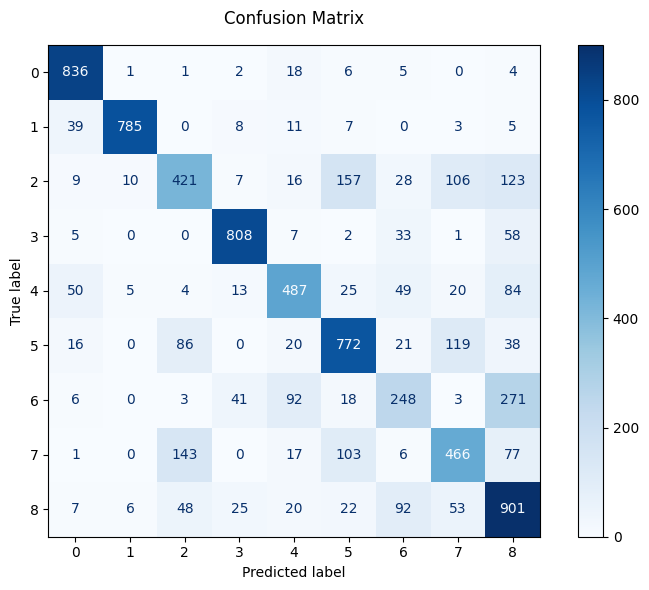

In [ ]:
save_path = "Checkpoint/Random Forest/grid_search.pkl"
grid_search = joblib.load(save_path)
best_rf_model = grid_search.best_estimator_
y_pred = best_rf_model.predict(X_test_pca)
print("\n" + "=" * 60)
print("          RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, digits=4))
print("=" * 60)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf_model.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title(f"Confusion Matrix", fontsize=12, pad=15)
plt.tight_layout()
plt.show()

### Fully connected neural network


          MLP TEST DATASET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.8529    0.9633    0.9048       873
           1     0.9762    0.9103    0.9421       858
           2     0.5116    0.4789    0.4947       877
           3     0.9340    0.8676    0.8996       914
           4     0.6753    0.6038    0.6375       737
           5     0.6540    0.6894    0.6712      1072
           6     0.4645    0.5279    0.4942       682
           7     0.5184    0.4674    0.4916       813
           8     0.6127    0.6508    0.6311      1174

    accuracy                         0.6904      8000
   macro avg     0.6889    0.6844    0.6852      8000
weighted avg     0.6926    0.6904    0.6902      8000



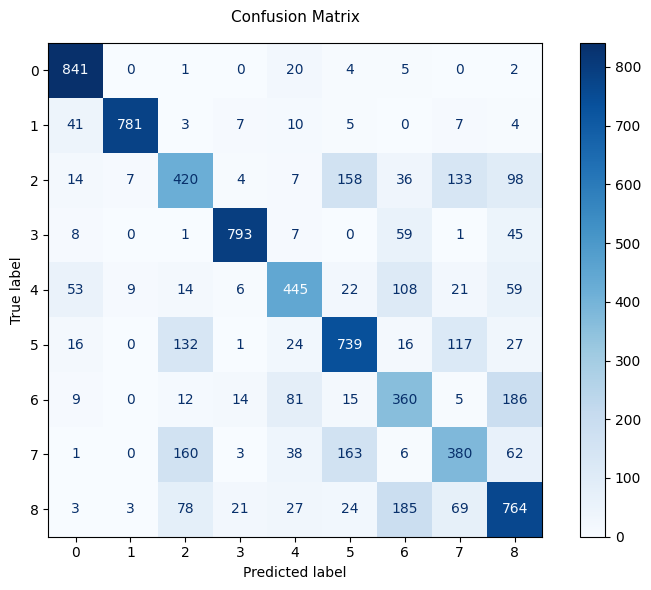

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.batch(128).prefetch(tf.data.AUTOTUNE)
ckpt_path = "Checkpoint/Multilayer Perceptron/MLP_h256-128-64_actrelu_lr0.001.keras"
model = tf.keras.models.load_model(ckpt_path, compile=True)
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    if len(labels.shape) > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    else:
        y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("\n" + "=" * 60)
print("          MLP TEST DATASET CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, digits=4))
print("=" * 60)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title(f"Confusion Matrix", fontsize=11, pad=15)
plt.tight_layout()
plt.show()

### Convolutional neural network


          CNN TEST DATASET CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.9977    0.9977    0.9977       873
           1     0.9977    0.9977    0.9977       858
           2     0.9577    0.9544    0.9560       877
           3     0.9902    0.9934    0.9918       914
           4     0.9719    0.9864    0.9791       737
           5     0.9707    0.9897    0.9801      1072
           6     0.9761    0.9589    0.9675       682
           7     0.9569    0.9287    0.9426       813
           8     0.9771    0.9804    0.9787      1174

    accuracy                         0.9775      8000
   macro avg     0.9773    0.9764    0.9768      8000
weighted avg     0.9774    0.9775    0.9774      8000



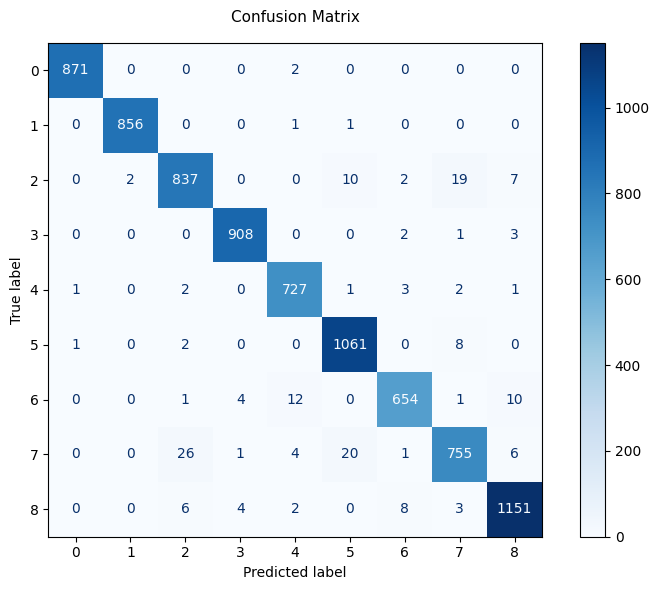

In [ ]:
ckpt_path = "Checkpoint/Convolutional Neural Network/CNN_f128-256_k5_lr0.001.keras"
model = tf.keras.models.load_model(ckpt_path, compile=True)
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    if len(labels.shape) > 1 and labels.shape[-1] > 1:
        y_true.extend(np.argmax(labels.numpy(), axis=1))
    else:
        y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)
print("\n" + "=" * 60)
print("          CNN TEST DATASET CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, digits=4))
print("=" * 60)
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format='d')
ax.set_title(f"Confusion Matrix", fontsize=11, pad=15)
plt.tight_layout()
plt.show()

## 6. AI Acknowledgement
Include acknowledgement of AI usage here.


We use AI to learn ways to improve accuracy and reference cutting-edge model techniques. We use AI to learn ways to improve accuracy and reference cutting-edge model techniques. Hyperparameter sets and the final model were designed manually.